Sorry that i turned it in late, my computer broke on friday while doing the assignment and had to use another computer that was not mine. I did turn in the assigment through an email on outlook, i hope that counts as turning it in on time.

---



In [ ]:
class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def get_value(self):
        if self.rank in ['Jack', 'Queen', 'King']:
            return 10
        elif self.rank == 'Ace':
            return 11
        else:
            return int(self.rank)

    def get_count_value(self):
        if self.rank in ['2', '3', '4', '5', '6']:
            return 1
        elif self.rank in ['7', '8', '9']:
            return 0
        else:
            return -1

    def __str__(self):
        return f"{self.rank} of {self.suit}"

    def __repr__(self):
        return f"Card('{self.suit}', '{self.rank}')"

    def __eq__(self, other):
        if not isinstance(other, Card):
            return NotImplemented
        return self.suit == other.suit and self.rank == other.rank

In [ ]:
class Hand:
    def __init__(self):
        self.cards = []
        self.value = 0
        self.aces = 0
    def add_card(self, card):

        self.cards.append(card)
        self.value += card.get_value()
        if card.rank == 'Ace':
            self.aces += 1
        self._adjust_for_ace()

    def _adjust_for_ace(self):

        while self.value > 21 and self.aces:
            self.value -= 10
            self.aces -= 1

    def __str__(self):
        return f"Cards: {', '.join(str(card) for card in self.cards)} - Value: {self.value}"

In [ ]:
deck = Deck(num_decks=1)

hand1 = Hand()
card1 = deck.deal_card()
card2 = deck.deal_card()
hand1.add_card(card1)
hand1.add_card(card2)
print(f"Hand 1: {hand1}")

hand2 = Hand()
hand2.add_card(Card('Hearts', 'King'))
hand2.add_card(Card('Spades', 'Ace'))
print(f"Hand 2 (King, Ace): {hand2}")

hand3 = Hand()
hand3.add_card(Card('Hearts', 'Ace'))
hand3.add_card(Card('Diamonds', 'Ace'))
hand3.add_card(Card('Clubs', 'King'))
print(f"Hand 3 (Ace, Ace, King): {hand3}")

hand4 = Hand()
hand4.add_card(deck.deal_card())
hand4.add_card(deck.deal_card())
print(f"Hand 4 (Dealt Cards): {hand4}")

Deck shuffled! 53 cards in the shoe.
Hand 1: Cards: 9 of Hearts, 6 of Clubs - Value: 15
Hand 2 (King, Ace): Cards: King of Hearts, Ace of Spades - Value: 21
Hand 3 (Ace, Ace, King): Cards: Ace of Hearts, Ace of Diamonds, King of Clubs - Value: 12
Hand 4 (Dealt Cards): Cards: Jack of Spades, 7 of Hearts - Value: 17


In [ ]:
class Deck:

    def __init__(self, num_decks=6, verbose=True):
        self.num_decks = num_decks
        self.cards = []
        self.plastic_card = Card('Plastic', 'Marker')
        self.running_count = 0
        self.verbose = verbose
        self._create_shoe()
        self.shuffle()
        self.reshuffle_next_hand = False

    def _create_shoe(self):

        suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
        ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'Jack', 'Queen', 'King', 'Ace']
        for _ in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))
        self._add_plastic_card()

    def _add_plastic_card(self):

        insert_position = random.randint(len(self.cards) * 2 // 3, len(self.cards) - 1)
        self.cards.insert(insert_position, self.plastic_card)

    def shuffle(self):

        random.shuffle(self.cards)
        self.reshuffle_next_hand = False
        self.running_count = 0
        if self.verbose:
            print(f"Deck shuffled! {len(self.cards)} cards in the shoe.")

    def deal_card(self):

        if not self.cards:
            if self.verbose:
                print("No cards left in the shoe. Reshuffling.")
            self._create_shoe()
            self.shuffle()

        card = self.cards.pop(0)
        if card == self.plastic_card:
            if self.verbose:
                print("Plastic card drawn! Deck will be reshuffled before the next hand.")
            self.reshuffle_next_hand = True

            return self.deal_card()

        self.running_count += card.get_count_value()
        return card

    def cards_remaining(self):
        return len([c for c in self.cards if c != self.plastic_card])

In [ ]:

deck = Deck(num_decks=6)

print("Dealing cards:")
for _ in range(5):
    card = deck.deal_card()
    print(f"  Dealt: {card}")

print(f"Cards remaining: {deck.cards_remaining()}")

print("\nDealing until plastic card is drawn (may take a while):")
plastic_card_found = False
while not plastic_card_found:
    card = deck.deal_card()
    if card.suit == 'Plastic' and card.rank == 'Marker':
        plastic_card_found = True
    if deck.reshuffle_next_hand:
        plastic_card_found = True

print(f"Reshuffle needed for next hand: {deck.reshuffle_next_hand}")

if deck.reshuffle_next_hand:
    deck._create_shoe()
    deck.shuffle()
    print(f"Cards remaining after reshuffle: {deck.cards_remaining()}")

Deck shuffled! 313 cards in the shoe.
Dealing cards:
  Dealt: Queen of Diamonds
  Dealt: 2 of Spades
  Dealt: 7 of Diamonds
  Dealt: Ace of Hearts
  Dealt: 2 of Diamonds
Cards remaining: 307

Dealing until plastic card is drawn (may take a while):
Plastic card drawn! Deck will be reshuffled before the next hand.
Reshuffle needed for next hand: True
Deck shuffled! 542 cards in the shoe.
Cards remaining after reshuffle: 541


problem 2

In [ ]:
class Player:
    def __init__(self, name, balance=1000, is_human=True, verbose=True):
        self.name = name
        self.hand = Hand()
        self.balance = balance
        self.is_human = is_human
        self.verbose = verbose

    def hit(self, deck):
        card = deck.deal_card()
        self.hand.add_card(card)
        if self.verbose:
            print(f"{self.name} hits and gets {card}. Current hand: {self.hand}")

    def stand(self):
        if self.verbose:
            print(f"{self.name} stands.")
        return True

In [ ]:
class CountingPlayer(Player):
    def __init__(self, name, balance=1000, is_human=False, threshold=0, verbose=True):
        super().__init__(name, balance, is_human, verbose=verbose)
        self.threshold = threshold

    def should_hit(self, dealer_up_card_value, deck_running_count):
        player_value = self.hand.value
        favorable_count = deck_running_count > self.threshold

        if player_value <= 11:
            return True

        elif 12 <= player_value <= 16:

            if dealer_up_card_value >= 7 or dealer_up_card_value == 10:
                return True
            else:
                if favorable_count and deck_running_count > (self.threshold + 2):
                     return True
                return False

        elif player_value >= 17:
            return False

        return False

    def place_bet(self, deck_running_count, minimum_bet):
        if deck_running_count > self.threshold:

            bet_multiplier = max(1, min(4, (deck_running_count - self.threshold) // 2 + 1))
            calculated_bet = minimum_bet * bet_multiplier
            return min(calculated_bet, self.balance)
        else:
            return min(minimum_bet, self.balance)

In [ ]:
class BlackjackGame:
    def __init__(self, num_decks=6, verbose=True):
        self.deck = Deck(num_decks=num_decks, verbose=verbose)
        self.dealer = Dealer(verbose=verbose)
        self.players = []
        self.verbose = verbose
        self.current_bets = {}

    def add_player(self, player):
        self.players.append(player)
        if self.verbose:
            print(f"Added player: {player.name}")

    def start_round(self, bet_amount=50):
        if self.verbose:
            print("\n--- Starting New Round ---")

        if self.deck.reshuffle_next_hand:
            self.deck.shuffle()

        for player in self.players:
            player.hand = Hand()
        self.dealer.hand = Hand()

        self.current_bets = {}
        for player in self.players:
            if isinstance(player, CountingPlayer):
                player_bet = player.place_bet(self.deck.running_count, bet_amount)
                self.current_bets[player.name] = player_bet
                if self.verbose:
                    print(f"{player.name} places a dynamic bet of {player_bet}")
            else:
                self.current_bets[player.name] = bet_amount
                if self.verbose:
                    print(f"{player.name} places a standard bet of {bet_amount}")

            if player.balance < self.current_bets[player.name]:
                if self.verbose:
                    print(f"{player.name} does not have enough balance for {self.current_bets[player.name]} bet. Betting remaining balance: {player.balance}")
                self.current_bets[player.name] = player.balance

        if self.verbose:
            print("Dealing initial cards...")
        for _ in range(2):
            for player in self.players:
                player.hit(self.deck)
                if self.verbose:
                    print(f"{player.name} gets {player.hand.cards[-1]}.")


            if _ == 0:
                card = self.deck.deal_card()
                self.dealer.hand.add_card(card)
                if self.verbose:
                    print(f"Dealer gets {card} (face up).")
                self.dealer_up_card = card
            else:
                self.dealer.hand.add_card(self.deck.deal_card())
                if self.verbose:
                    print("Dealer gets a face down card.")


        if self.verbose:
            print(f"\nDealer's face-up card: {self.dealer_up_card}")
        for player in self.players:
            if self.verbose:
                print(f"{player.name}'s hand: {player.hand}")
            if player.hand.value == 21 and len(player.hand.cards) == 2:
                if self.verbose:
                    print(f"{player.name} has Blackjack!")
                continue
            self._handle_player_turn(player, self.dealer_up_card.get_value())


        self._handle_dealer_turn()

        if self.verbose:
            print("\n--- Resolving Hands ---")
        for player in self.players:

            bet_for_player = self.current_bets.get(player.name, bet_amount)
            self._resolve_hand(player, bet_for_player)


    def _handle_player_turn(self, player, dealer_up_card_value):
        if self.verbose:
            print(f"\n{player.name}'s turn.")
        while player.hand.value < 21:
            if isinstance(player, CountingPlayer):
                if player.should_hit(dealer_up_card_value, self.deck.running_count):
                    player.hit(self.deck)
                else:
                    player.stand()
                    break
            elif player.is_human:

                player.hit(self.deck)
                if player.hand.value > 21:
                    if self.verbose:
                        print(f"{player.name} busts with {player.hand}!")
            else:
                if player.hand.value < 17:
                    player.hit(self.deck)
                else:
                    player.stand()
                    break
            if player.hand.value > 21:
                if self.verbose:
                    print(f"{player.name} busts with {player.hand}!")

        if player.hand.value == 21 and not (player.hand.value == 21 and len(player.hand.cards) == 2):
            if self.verbose:
                print(f"{player.name} stands with {player.hand}!")



    def _handle_dealer_turn(self):
        if self.verbose:
            print("\n--- Dealer's Turn ---")
        if self.verbose:
            print(f"Dealer's hand revealed: {self.dealer.hand}")
        while self.dealer.hand.value < 17:
            self.dealer.hit(self.deck)
        if self.dealer.hand.value > 21:
            if self.verbose:
                print(f"Dealer busts with {self.dealer.hand}!")
        else:
            if self.verbose:
                print(f"Dealer stands with {self.dealer.hand}!")

    def _resolve_hand(self, player, bet_amount):
        if self.verbose:
            print(f"\n{player.name} final hand: {player.hand}")
            print(f"Dealer final hand: {self.dealer.hand}")

        player_value = player.hand.value
        dealer_value = self.dealer.hand.value

        if player_value > 21:
            if self.verbose:
                print(f"{player.name} lose! Balance change: -{bet_amount}. New balance: {player.balance - bet_amount}")
            player.balance -= bet_amount
        elif dealer_value > 21:
            if self.verbose:
                print(f"{player.name} win! Balance change: {bet_amount}. New balance: {player.balance + bet_amount}")
            player.balance += bet_amount
        elif player_value > dealer_value:
            if self.verbose:
                print(f"{player.name} win! Balance change: {bet_amount}. New balance: {player.balance + bet_amount}")
            player.balance += bet_amount
        elif player_value < dealer_value:
            if self.verbose:
                print(f"{player.name} lose! Balance change: -{bet_amount}. New balance: {player.balance - bet_amount}")
            player.balance -= bet_amount
        else:
            if self.verbose:
                print(f"{player.name} push! Balance change: 0. New balance: {player.balance}")



problem 3

 UML Class Diagram Description for Blackjack Game

1. `Card` Class
  **Attributes**:
    *   `suit`: `str` (e.g., 'Hearts', 'Spades')
    *   `rank`: `str` (e.g., '2', 'Ace', 'King')
 **Methods**:
    *   `__init__(self, suit: str, rank: str)`
    *   `get_value(self) -> int`
    *   `__str__(self) -> str`
    *   `__repr__(self) -> str`
    *   `__eq__(self, other: 'Card') -> bool`

### 2. `Hand` Class
*   **Attributes**:
    *   `cards`: `List[Card]`
    *   `value`: `int`
    *   `aces`: `int`
*   **Methods**:
    *   `__init__(self)`
    *   `add_card(self, card: Card)`
    *   `_adjust_for_ace(self)` (private)
    *   `__str__(self) -> str`

### 3. `Deck` Class
*   **Attributes**:
    *   `num_decks`: `int`
    *   `cards`: `List[Card]`
    *   `plastic_card`: `Card`
    *   `reshuffle_next_hand`: `bool`
*   **Methods**:
    *   `__init__(self, num_decks: int = 6)`
    *   `_create_shoe(self)` (private)
    *   `_add_plastic_card(self)` (private)
    *   `shuffle(self)`
    *   `deal_card(self) -> Card`
    *   `cards_remaining(self) -> int`

### 4. `Player` Class
*   **Attributes**:
    *   `name`: `str`
    *   `hand`: `Hand`
    *   `balance`: `int`
*   **Methods**:
    *   `__init__(self, name: str, balance: int = 1000)`
    *   `hit(self, deck: Deck)`
    *   `stand(self) -> bool`

### 5. `Dealer` Class
*   **Attributes**:
    *   `name`: `str` (default: "Dealer")
    *   `hand`: `Hand`
*   **Methods**:
    *   `__init__(self)`
    *   `hit(self, deck: Deck)`
    *   `stand(self)`

### 6. `BlackjackGame` Class
*   **Attributes**:
    *   `deck`: `Deck`
    *   `dealer`: `Dealer`
    *   `players`: `List[Player]`
*   **Methods**:
    *   `__init__(self, num_decks: int = 6)`
    *   `add_player(self, player: Player)`
    *   `start_round(self, bet_amount: int = 100)`
    *   `_handle_player_turn(self, player: Player)` (private)
    *   `_handle_dealer_turn(self)` (private)
    *   `_resolve_hand(self, player: Player, bet_amount: int)` (private)



problem 5 tests for multi-player rounds

In [ ]:
def run_game_scenario(num_players, num_rounds, num_decks=2, initial_balance=1000, bet_amount=50):

    print(f"\n--- Running Blackjack Game Scenario with {num_players} Players for {num_rounds} Rounds ---")

    game = BlackjackGame(num_decks=num_decks)
    for i in range(num_players):
        player_name = f"AI Player {i + 1}"
        player = Player(player_name, balance=initial_balance, is_human=False)
        game.add_player(player)
    for i in range(num_rounds):
        print(f"\n===== Round {i + 1} =====")
        game.start_round(bet_amount=bet_amount)

    print("\n--- Scenario Complete: Final Balances ---")
    for player in game.players:
        print(f"Final Balance for {player.name}: {player.balance}")

3 players

In [ ]:
run_game_scenario(num_players=3, num_rounds=3)


--- Running Blackjack Game Scenario with 3 Players for 3 Rounds ---
Deck shuffled! 105 cards in the shoe.
Added player: AI Player 1
Added player: AI Player 2
Added player: AI Player 3

===== Round 1 =====

--- Starting New Round ---
Dealing initial cards...
AI Player 1 gets 9 of Hearts.
AI Player 2 gets Queen of Clubs.
AI Player 3 gets 5 of Clubs.
Dealer gets 4 of Hearts (face up).
AI Player 1 gets 3 of Spades.
AI Player 2 gets 7 of Diamonds.
AI Player 3 gets 7 of Clubs.
Dealer gets a face down card.

Dealer's face-up card: 4 of Hearts
AI Player 1's hand: Cards: 9 of Hearts, 3 of Spades - Value: 12
AI Player 2's hand: Cards: Queen of Clubs, 7 of Diamonds - Value: 17
AI Player 3's hand: Cards: 5 of Clubs, 7 of Clubs - Value: 12

AI Player 1's turn.
AI Player 1 hits and gets 3 of Diamonds. Current hand: Cards: 9 of Hearts, 3 of Spades, 3 of Diamonds - Value: 15
AI Player 1 hits and gets 9 of Diamonds. Current hand: Cards: 9 of Hearts, 3 of Spades, 3 of Diamonds, 9 of Diamonds - Value: 2

7 players

In [ ]:
run_game_scenario(num_players=7, num_rounds=3)


--- Running Blackjack Game Scenario with 7 Players for 3 Rounds ---
Deck shuffled! 105 cards in the shoe.
Added player: AI Player 1
Added player: AI Player 2
Added player: AI Player 3
Added player: AI Player 4
Added player: AI Player 5
Added player: AI Player 6
Added player: AI Player 7

===== Round 1 =====

--- Starting New Round ---
Dealing initial cards...
AI Player 1 gets 10 of Hearts.
AI Player 2 gets 9 of Hearts.
AI Player 3 gets Ace of Diamonds.
AI Player 4 gets Ace of Hearts.
AI Player 5 gets King of Diamonds.
AI Player 6 gets 2 of Clubs.
AI Player 7 gets 2 of Spades.
Dealer gets 3 of Hearts (face up).
AI Player 1 gets 9 of Clubs.
AI Player 2 gets 8 of Diamonds.
AI Player 3 gets 8 of Clubs.
AI Player 4 gets 9 of Spades.
AI Player 5 gets 2 of Hearts.
AI Player 6 gets 7 of Clubs.
AI Player 7 gets 10 of Hearts.
Dealer gets a face down card.

Dealer's face-up card: 3 of Hearts
AI Player 1's hand: Cards: 10 of Hearts, 9 of Clubs - Value: 19
AI Player 2's hand: Cards: 9 of Hearts, 8

testing for 50 rounds

In [ ]:
def run_counting_strategy_test(num_rounds, counting_player_threshold, num_other_ai_players, num_decks=6, initial_balance=1000, bet_amount=50, verbose=False):

    if verbose:
        print(f"\n--- Running Counting Strategy Test with {num_other_ai_players} AI Players, {num_rounds} Rounds, and Threshold {counting_player_threshold} ---")

    game = BlackjackGame(num_decks=num_decks, verbose=verbose)

    counting_player = CountingPlayer("Counting Player", balance=initial_balance, threshold=counting_player_threshold, verbose=verbose)
    game.add_player(counting_player)

    for i in range(num_other_ai_players):
        player_name = f"AI Player {i + 1}"
        ai_player = Player(player_name, balance=initial_balance, is_human=False, verbose=verbose)
        game.add_player(ai_player)

    if verbose:
        print(f"Initial Balance for {counting_player.name}: {counting_player.balance}")
        for player in game.players[1:]:
            print(f"Initial Balance for {player.name}: {player.balance}")

    for i in range(num_rounds):
        if verbose:
            print(f"\n===== Round {i + 1} =====")
        game.start_round(bet_amount=bet_amount)

    if verbose:
        print("\n--- Scenario Complete: Final Balances ---")
        print(f"Final Balance for {counting_player.name}: {counting_player.balance}")
        for player in game.players[1:]:
            print(f"Final Balance for {player.name}: {player.balance}")

    return counting_player.balance

In [ ]:
run_counting_strategy_test(num_rounds=50, counting_player_threshold=2, num_other_ai_players=2)


--- Running Counting Strategy Test with 2 AI Players, 50 Rounds, and Threshold 2 ---
Initial Balance for Counting Player: 1000
Initial Balance for AI Player 1: 1000
Initial Balance for AI Player 2: 1000

===== Round 1 =====

===== Round 2 =====

===== Round 3 =====

===== Round 4 =====

===== Round 5 =====

===== Round 6 =====

===== Round 7 =====

===== Round 8 =====

===== Round 9 =====

===== Round 10 =====

===== Round 11 =====

===== Round 12 =====

===== Round 13 =====

===== Round 14 =====

===== Round 15 =====

===== Round 16 =====

===== Round 17 =====

===== Round 18 =====

===== Round 19 =====

===== Round 20 =====

===== Round 21 =====

===== Round 22 =====

===== Round 23 =====

===== Round 24 =====

===== Round 25 =====

===== Round 26 =====

===== Round 27 =====

===== Round 28 =====

===== Round 29 =====

===== Round 30 =====

===== Round 31 =====

===== Round 32 =====

===== Round 33 =====

===== Round 34 =====

===== Round 35 =====

===== Round 36 =====

===== Round 

problem 8

In [ ]:
class Dealer(Player):
    def __init__(self, verbose=True):
        super().__init__("Dealer", balance=0, is_human=False, verbose=verbose)

In [ ]:
num_simulations = 100
num_rounds_per_sim = 50
counting_player_threshold_val = 2
num_other_ai_players_val = 2
initial_balance_val = 1000

final_balances = []

print(f"Running {num_simulations} simulations...")
for i in range(num_simulations):
    if (i + 1) % 10 == 0:
        print(f"  Simulation {i + 1}/{num_simulations}...")
    final_balance = run_counting_strategy_test(
        num_rounds=num_rounds_per_sim,
        counting_player_threshold=counting_player_threshold_val,
        num_other_ai_players=num_other_ai_players_val,
        initial_balance=initial_balance_val,
        verbose=False
    )
    final_balances.append(final_balance)

print("\nSimulations complete!")

Running 100 simulations...
  Simulation 10/100...
  Simulation 20/100...
  Simulation 30/100...
  Simulation 40/100...
  Simulation 50/100...
  Simulation 60/100...
  Simulation 70/100...
  Simulation 80/100...
  Simulation 90/100...
  Simulation 100/100...

Simulations complete!



--- Simulation Analysis Results ---
Number of simulations: 100
Initial balance for Counting Player: 1000
Rounds per simulation: 50
Counting Player Threshold: 2
Average Final Balance: 804.00
Standard Deviation of Final Balances: 597.31
Average Winnings per Simulation: -196.00
Average Winnings per Round: -3.92
Probability of a Net Win: 32.00%
Probability of a Net Loss: 67.00%
Number of Net Wins: 32
Number of Net Losses: 67
Number of Net Pushes: 1


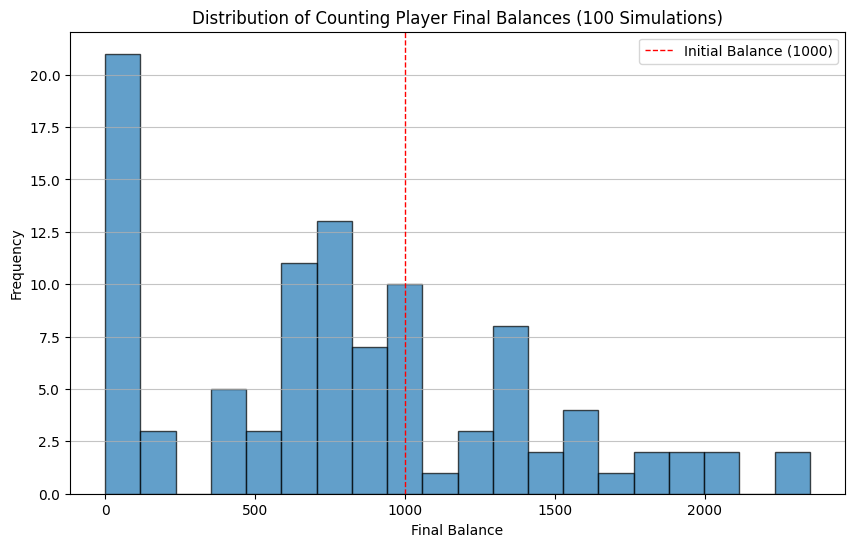

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

final_balances_np = np.array(final_balances)

average_final_balance = np.mean(final_balances_np)
std_dev_final_balance = np.std(final_balances_np)

total_winnings = final_balances_np - initial_balance_val
average_winnings_per_simulation = np.mean(total_winnings)
average_winnings_per_round = average_winnings_per_simulation / num_rounds_per_sim

num_wins = np.sum(final_balances_np > initial_balance_val)
num_losses = np.sum(final_balances_np < initial_balance_val)
num_pushes = np.sum(final_balances_np == initial_balance_val)

probability_net_win = num_wins / num_simulations
probability_net_loss = num_losses / num_simulations

print("\n--- Simulation Analysis Results ---")
print(f"Number of simulations: {num_simulations}")
print(f"Initial balance for Counting Player: {initial_balance_val}")
print(f"Rounds per simulation: {num_rounds_per_sim}")
print(f"Counting Player Threshold: {counting_player_threshold_val}")
print(f"Average Final Balance: {average_final_balance:.2f}")
print(f"Standard Deviation of Final Balances: {std_dev_final_balance:.2f}")
print(f"Average Winnings per Simulation: {average_winnings_per_simulation:.2f}")
print(f"Average Winnings per Round: {average_winnings_per_round:.2f}")
print(f"Probability of a Net Win: {probability_net_win:.2%}")
print(f"Probability of a Net Loss: {probability_net_loss:.2%}")
print(f"Number of Net Wins: {num_wins}")
print(f"Number of Net Losses: {num_losses}")
print(f"Number of Net Pushes: {num_pushes}")

# histogram
plt.figure(figsize=(10, 6))
plt.hist(final_balances_np, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(initial_balance_val, color='red', linestyle='dashed', linewidth=1, label=f'Initial Balance ({initial_balance_val})')
plt.title('Distribution of Counting Player Final Balances (100 Simulations)')
plt.xlabel('Final Balance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

The probability of net losses is 67%, while net wins is 32%. Meaning you would have a much greater probability of net losses.

problem 9

In [ ]:
threshold_values_to_test = [-5, -2, 0, 2, 5, 8, 10]
print("Defined threshold_values_to_test:", threshold_values_to_test)

Defined threshold_values_to_test: [-5, -2, 0, 2, 5, 8, 10]


In [ ]:
all_threshold_results = {}

num_simulations = 100
num_rounds_per_sim = 50
bet_amount = 50

for threshold_value in threshold_values_to_test:
    print(f"\n--- Running simulations for Threshold: {threshold_value} ---")
    current_threshold_balances = []

    for i in range(num_simulations):
        if (i + 1) % 10 == 0:
            print(f"  Simulation {i + 1}/{num_simulations} for threshold {threshold_value}...")

        final_balance = run_counting_strategy_test(
            num_rounds=num_rounds_per_sim,
            counting_player_threshold=threshold_value,
            num_other_ai_players=num_other_ai_players_val,
            initial_balance=initial_balance_val,
            bet_amount=bet_amount,
            verbose=False
        )
        current_threshold_balances.append(final_balance)

    all_threshold_results[threshold_value] = current_threshold_balances

print("\nAll threshold simulations complete!")


--- Running simulations for Threshold: -5 ---
  Simulation 10/100 for threshold -5...
  Simulation 20/100 for threshold -5...
  Simulation 30/100 for threshold -5...
  Simulation 40/100 for threshold -5...
  Simulation 50/100 for threshold -5...
  Simulation 60/100 for threshold -5...
  Simulation 70/100 for threshold -5...
  Simulation 80/100 for threshold -5...
  Simulation 90/100 for threshold -5...
  Simulation 100/100 for threshold -5...

--- Running simulations for Threshold: -2 ---
  Simulation 10/100 for threshold -2...
  Simulation 20/100 for threshold -2...
  Simulation 30/100 for threshold -2...
  Simulation 40/100 for threshold -2...
  Simulation 50/100 for threshold -2...
  Simulation 60/100 for threshold -2...
  Simulation 70/100 for threshold -2...
  Simulation 80/100 for threshold -2...
  Simulation 90/100 for threshold -2...
  Simulation 100/100 for threshold -2...

--- Running simulations for Threshold: 0 ---
  Simulation 10/100 for threshold 0...
  Simulation 20/100


--- Analysis of Counting Player Performance Across Thresholds ---

Threshold: -5
  Average Final Balance: 709.50
  Standard Deviation of Final Balances: 795.95
  Net Wins: 35 (35.00%)
  Net Losses: 64 (64.00%)
  Net Pushes: 1

Threshold: -2
  Average Final Balance: 598.00
  Standard Deviation of Final Balances: 628.25
  Net Wins: 26 (26.00%)
  Net Losses: 71 (71.00%)
  Net Pushes: 3

Threshold: 0
  Average Final Balance: 789.00
  Standard Deviation of Final Balances: 607.07
  Net Wins: 38 (38.00%)
  Net Losses: 60 (60.00%)
  Net Pushes: 2

Threshold: 2
  Average Final Balance: 765.00
  Standard Deviation of Final Balances: 546.92
  Net Wins: 36 (36.00%)
  Net Losses: 59 (59.00%)
  Net Pushes: 5

Threshold: 5
  Average Final Balance: 813.50
  Standard Deviation of Final Balances: 416.94
  Net Wins: 32 (32.00%)
  Net Losses: 65 (65.00%)
  Net Pushes: 3

Threshold: 8
  Average Final Balance: 844.00
  Standard Deviation of Final Balances: 395.93
  Net Wins: 34 (34.00%)
  Net Losses: 62 (6

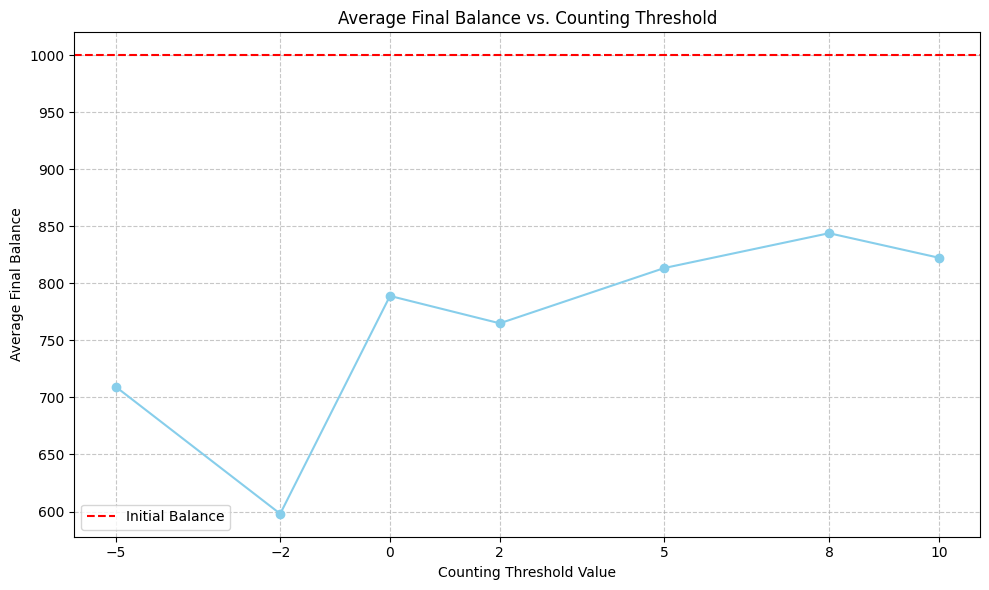

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Analysis of Counting Player Performance Across Thresholds ---")

threshold_averages = {}
threshold_std_devs = {}
threshold_net_wins = {}
threshold_net_losses = {}
threshold_net_pushes = {}
threshold_win_probabilities = {}

for threshold, balances in all_threshold_results.items():
    balances_np = np.array(balances)
    average_balance = np.mean(balances_np)
    std_dev_balance = np.std(balances_np)

    winnings = balances_np - initial_balance_val
    num_wins = np.sum(winnings > 0)
    num_losses = np.sum(winnings < 0)
    num_pushes = np.sum(winnings == 0)
    win_probability = num_wins / num_simulations

    threshold_averages[threshold] = average_balance
    threshold_std_devs[threshold] = std_dev_balance
    threshold_net_wins[threshold] = num_wins
    threshold_net_losses[threshold] = num_losses
    threshold_net_pushes[threshold] = num_pushes
    threshold_win_probabilities[threshold] = win_probability

    print(f"\nThreshold: {threshold}")
    print(f"  Average Final Balance: {average_balance:.2f}")
    print(f"  Standard Deviation of Final Balances: {std_dev_balance:.2f}")
    print(f"  Net Wins: {num_wins} ({win_probability:.2%})")
    print(f"  Net Losses: {num_losses} ({num_losses / num_simulations:.2%})")
    print(f"  Net Pushes: {num_pushes}")



thresholds = sorted(threshold_averages.keys())
averages = [threshold_averages[t] for t in thresholds]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, averages, marker='o', linestyle='-', color='skyblue')
plt.axhline(initial_balance_val, color='red', linestyle='--', label='Initial Balance')
plt.title('Average Final Balance vs. Counting Threshold')
plt.xlabel('Counting Threshold Value')
plt.ylabel('Average Final Balance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(thresholds)
plt.legend()
plt.tight_layout()
plt.show()


As shown through the graphs, it appears as the best value for the threshold is 8.

```markdown
## Categorize Strategy Types

### Subtask:
Identify different categories of blackjack strategies we could explore, such as basic strategy refinements, advanced counting methods, or dynamic betting systems.

#### Instructions
1. Consider various aspects of a blackjack game where strategy can be applied, such as how players decide to hit or stand, how they manage their bets, and what information they use to make these decisions.
2. Brainstorm broad categories for these strategies. Think about the fundamental differences in approach. For example, some strategies might focus on the cards dealt, while others might focus on the money being wagered or general optimal play.
3. List at least three distinct categories of blackjack strategies that could be implemented or explored.